<a href="https://colab.research.google.com/github/sukritimahajan35/Hindi-Audio-Sentiment-Analysis-Using-Machine-Learning-and-Deep-Learning/blob/main/CNN%2C_Stacking%2C_Voting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Dataset Path
dataset_path = '/content/drive/MyDrive/Dataset'
os.chdir(dataset_path)

Mounted at /content/drive


In [ ]:
# Extract Dataset
def extract_dataset(base_path):
    data = []
    emotions = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']
    actor_folders = sorted(os.listdir(base_path), key=lambda x: int(x))

    for actor_folder in actor_folders:
        actor_path = os.path.join(base_path, actor_folder)
        if os.path.isdir(actor_path):
            session_folders = sorted(os.listdir(actor_path), key=lambda x: int(x.split('session')[-1]))
            for session_folder in session_folders:
                session_path = os.path.join(actor_path, session_folder)
                if os.path.isdir(session_path):
                    for emotion in emotions:
                        emotion_path = os.path.join(session_path, emotion)
                        if os.path.isdir(emotion_path):
                            audio_files = sorted(os.listdir(emotion_path), key=lambda x: int(x.split('-')[-1].split('.')[0]))
                            for audio_file in audio_files:
                                data.append((os.path.join(emotion_path, audio_file), emotion))
    return pd.DataFrame(data, columns=['file_path', 'emotion'])

df = extract_dataset(dataset_path)
print(df.head())

                                           file_path emotion
0  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
1  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
2  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
3  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
4  /content/drive/MyDrive/Dataset/1/session1/ange...   anger


In [ ]:
# Noise Reduction
def reduce_noise(y, sr):
    return librosa.effects.preemphasis(y)

# Silence Removal
def remove_silence(y, sr, top_db=20):
    intervals = librosa.effects.split(y, top_db=top_db)
    y_silence_removed = np.concatenate([y[start:end] for start, end in intervals])
    return y_silence_removed

In [ ]:
# Feature Extraction
def extract_features(y, sr):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)
    zcr = librosa.feature.zero_crossing_rate(y).mean()
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    chroma = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1)
    rms = librosa.feature.rms(y=y).mean()
    feature_vector = np.hstack([mfccs, zcr, spectral_centroid, chroma, rms])
    return feature_vector

In [ ]:
# Preprocessing Pipeline
def preprocess_data(df):
    features = []
    labels = []
    for idx, row in df.iterrows():
        try:
            y, sr = librosa.load(row['file_path'], sr=None)
            y = reduce_noise(y, sr)  # Step 1: Noise Reduction
            y = remove_silence(y, sr)  # Step 2: Silence Removal
            feature_vector = extract_features(y, sr)  # Step 3: Feature Extraction
            features.append(feature_vector)
            labels.append(row['emotion'])
        except Exception as e:
            print(f"Error processing file {row['file_path']}: {e}")
    features = np.array(features)
    scaler = StandardScaler()
    features = scaler.fit_transform(features)  # Step 4: Normalization
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(labels)
    return features, y_encoded, label_encoder

# Apply Preprocessing
X, y, label_encoder = preprocess_data(df)

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape Data for CNN Models
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build and Train CNN Model
model_cnn = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])
model_cnn.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cnn = model_cnn.fit(X_train_cnn, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate CNN Model
cnn_accuracy = model_cnn.evaluate(X_test_cnn, y_test)[1]
print(f"CNN Accuracy: {cnn_accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2028 - loss: 2.0285 - val_accuracy: 0.2656 - val_loss: 1.9291
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3650 - loss: 1.7832 - val_accuracy: 0.3320 - val_loss: 1.7748
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4151 - loss: 1.6277 - val_accuracy: 0.4043 - val_loss: 1.6750
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4581 - loss: 1.5112 - val_accuracy: 0.3750 - val_loss: 1.6602
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4886 - loss: 1.4217 - val_accuracy: 0.4023 - val_loss: 1.5944
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5284 - loss: 1.3368 - val_accuracy: 0.4316 - val_loss: 1.5912
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5473 - loss: 1.2909 - val_accuracy: 0.4043 - val_loss: 1.5996
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5706 - loss: 1.2165 - val_accuracy: 0.4453 - val_loss

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

Classification Report:
               precision    recall  f1-score   support

       anger       0.74      0.66      0.70        82
     disgust       0.64      0.41      0.50        87
        fear       0.52      0.60      0.56        70
       happy       0.55      0.65      0.60        71
     neutral       0.60      0.69      0.64        86
         sad       0.60      0.57      0.58        76
   sarcastic       0.46      0.54      0.49        89
    surprise       0.61      0.54      0.57        79

    accuracy                           0.58       640
   macro avg       0.59      0.58      0.58       640
weighted avg       0.59      0.58      0.58       640



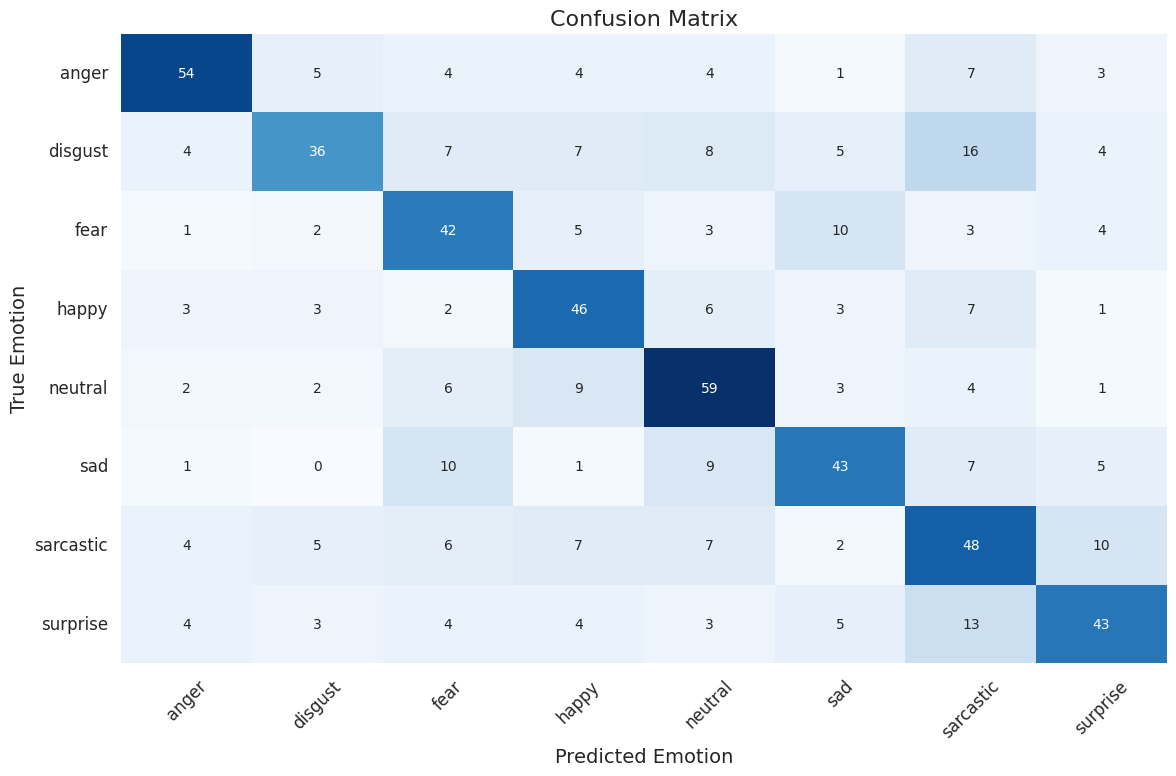

In [ ]:
# Predictions
y_pred = np.argmax(model_cnn.predict(X_test_cnn), axis=1)

# Classification Report
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("\nClassification Report:\n", report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={"size": 10}, cbar=False)

# Add Labels and Title
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Emotion', fontsize=14)
plt.ylabel('True Emotion', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
# Define Base Models
svm = SVC(kernel='linear', probability=True)
rf = RandomForestClassifier()
knn = KNeighborsClassifier()

# Hyperparameter Grids for Each Model
svm_param_grid = {'C': [0.1, 1, 10]}
rf_param_grid = {'n_estimators': [50, 100, 200]}
knn_param_grid = {'n_neighbors': [3, 5, 7]}

# Perform GridSearchCV for Each Model
svm_grid = GridSearchCV(svm, svm_param_grid, cv=3, scoring='accuracy')
rf_grid = GridSearchCV(rf, rf_param_grid, cv=3, scoring='accuracy')
knn_grid = GridSearchCV(knn, knn_param_grid, cv=3, scoring='accuracy')

svm_grid.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)
knn_grid.fit(X_train, y_train)

# Create Voting Classifier
ensemble = VotingClassifier(estimators=[
    ('svm', svm_grid.best_estimator_),
    ('rf', rf_grid.best_estimator_),
    ('knn', knn_grid.best_estimator_)
], voting='soft')  # Soft voting uses predicted probabilities

# Train Voting Classifier
ensemble.fit(X_train, y_train)

# Evaluate Accuracy
y_pred_ensemble = ensemble.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
print(f"Voting Classifier Accuracy: {ensemble_accuracy:.4f}")

Voting Classifier Accuracy: 0.6453


In [ ]:
# Define Final Estimator (Meta-Model)
final_estimator = LogisticRegression()

# Create Stacking Classifier
stacking = StackingClassifier(estimators=[
    ('svm', svm_grid.best_estimator_),
    ('rf', rf_grid.best_estimator_),
    ('knn', knn_grid.best_estimator_)
], final_estimator=final_estimator)

# Hyperparameter Grid for Final Estimator
param_grid_stacking = {
    'final_estimator__C': [0.1, 1, 10]
}

# Perform GridSearchCV for Stacking Classifier
grid_stacking = GridSearchCV(stacking, param_grid_stacking, cv=3, scoring='accuracy')
grid_stacking.fit(X_train, y_train)

# Evaluate Accuracy
y_pred_stacking = grid_stacking.predict(X_test)
stacking_accuracy = accuracy_score(y_test, y_pred_stacking)
print(f"Stacking Classifier Accuracy: {stacking_accuracy:.4f}")

Stacking Classifier Accuracy: 0.6531


Classification Report for Voting Classifier:
              precision    recall  f1-score   support

       anger       0.74      0.73      0.74        82
     disgust       0.63      0.60      0.62        87
        fear       0.61      0.71      0.66        70
       happy       0.57      0.62      0.59        71
     neutral       0.69      0.70      0.69        86
         sad       0.60      0.64      0.62        76
   sarcastic       0.67      0.49      0.57        89
    surprise       0.64      0.68      0.66        79

    accuracy                           0.65       640
   macro avg       0.65      0.65      0.64       640
weighted avg       0.65      0.65      0.64       640


Classification Report for Stacking Classifier:
              precision    recall  f1-score   support

       anger       0.78      0.78      0.78        82
     disgust       0.69      0.63      0.66        87
        fear       0.64      0.71      0.68        70
       happy       0.55      0.59      

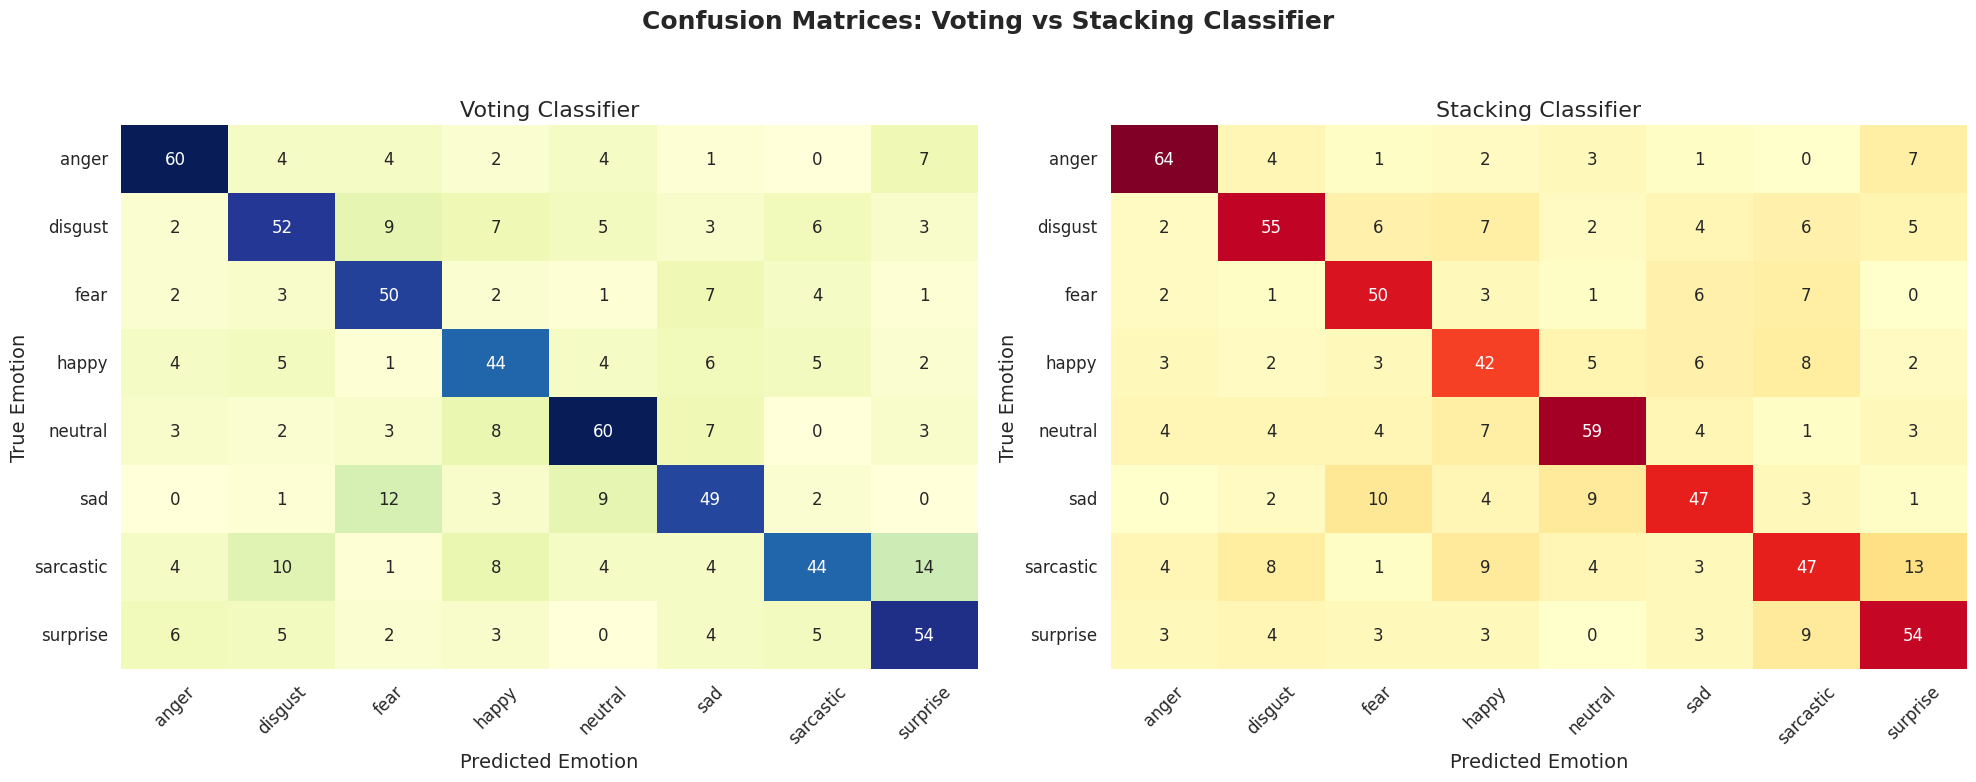

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Compute Confusion Matrices
cm_voting = confusion_matrix(y_test, y_pred_ensemble)
cm_stacking = confusion_matrix(y_test, y_pred_stacking)

# Print Classification Reports Only
print("Classification Report for Voting Classifier:")
print(classification_report(y_test, y_pred_ensemble, target_names=label_encoder.classes_))

print("\nClassification Report for Stacking Classifier:")
print(classification_report(y_test, y_pred_stacking, target_names=label_encoder.classes_))

# Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_voting, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={"size": 12}, cbar=False, ax=axes[0])
axes[0].set_title('Voting Classifier', fontsize=16)
axes[0].set_xlabel('Predicted Emotion', fontsize=14)
axes[0].set_ylabel('True Emotion', fontsize=14)
axes[0].tick_params(axis='x', rotation=45, labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)

sns.heatmap(cm_stacking, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={"size": 12}, cbar=False, ax=axes[1])
axes[1].set_title('Stacking Classifier', fontsize=16)
axes[1].set_xlabel('Predicted Emotion', fontsize=14)
axes[1].set_ylabel('True Emotion', fontsize=14)
axes[1].tick_params(axis='x', rotation=45, labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)

plt.suptitle('Confusion Matrices: Voting vs Stacking Classifier', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()